<a href="https://colab.research.google.com/github/antonbeski0/lstm_market_dynamics/blob/main/geometric_brownian_motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

In [14]:
def gbm(n_years=10, n_scenarios=100, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
    dt = 1/steps_per_year
    n_steps = n_years*steps_per_year
    rets_p_1 = np.random.normal(loc=(1+mu)**dt, scale=(sigma*np.sqrt(dt)), size=(n_steps, n_scenarios))
    rets_p_1 = pd.concat([pd.DataFrame(np.ones((1, n_scenarios))), pd.DataFrame(rets_p_1)], ignore_index=True)
    return s_0*rets_p_1.cumprod()

/tmp/ipykernel_4276/3485434540.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2020-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


Displaying first 5 rows of COALINDIA.NS data:
Price             Close         High          Low         Open       Volume
Ticker     COALINDIA.NS COALINDIA.NS COALINDIA.NS COALINDIA.NS COALINDIA.NS
Date                                                                       
2020-01-01   116.761429   117.119513   114.805763   116.430899      6447592
2020-01-02   116.293182   117.229696   114.750685   117.064427      5958343
2020-01-03   116.706345   117.119513   114.420140   115.687192      6452638
2020-01-06   113.318375   115.659663   112.078869   115.659663      6853058
2020-01-07   113.318375   114.695603   112.574676   113.759089      5243225


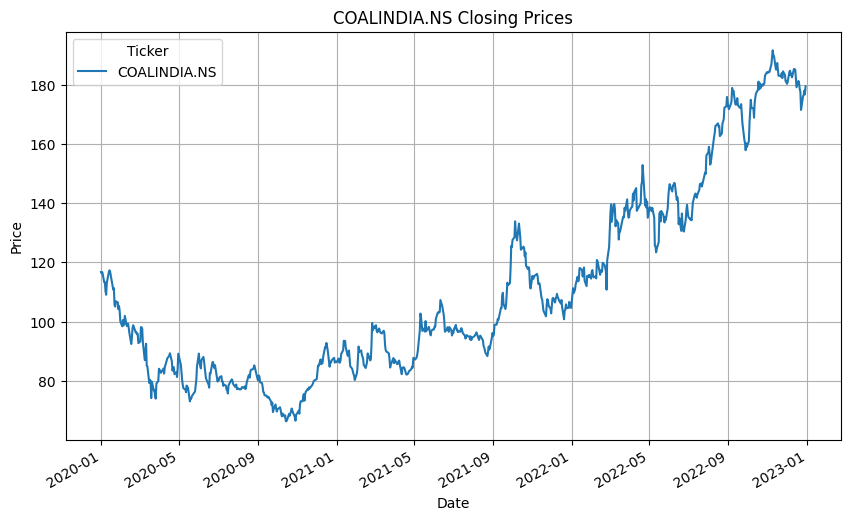

In [15]:
!pip install yfinance
import yfinance as yf

# Download historical data for a stock (e.g., Apple - AAPL)
ticker = 'COALINDIA.NS'
data = yf.download(ticker, start='2020-01-01', end='2023-01-01')

print(f"Displaying first 5 rows of {ticker} data:")
print(data.head())

import matplotlib.pyplot as plt
data['Close'].plot(title=f'{ticker} Closing Prices', figsize=(10, 6))
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [16]:
def interactive_gbm(n_years=10, n_scenarios=100, mu=0.07, sigma=0.15, s_0=100):
    prices = gbm(n_years=n_years, n_scenarios=n_scenarios, mu=mu, sigma=sigma, s_0=s_0)
    terminal_wealth = prices.iloc[-1]

    fig, (wealth_ax, hist_ax) = plt.subplots(nrows=1, ncols=2, sharey=True, gridspec_kw={'width_ratios':[2,1]}, figsize=(24, 10))
    plt.subplots_adjust(wspace=0)

    prices.plot(ax=wealth_ax, legend=False, color='skyblue')
    wealth_ax.axhline(y=s_0, ls="--", color='black')
    terminal_wealth.plot.hist(ax=hist_ax, bins=50, ec='white', color='skyblue', orientation='horizontal')

In [17]:
widgets.interactive(interactive_gbm, n_years=(1, 30), n_scenarios=(1, 1000), mu=(-0.1, .1, 0.01), sigma=(0, 0.3, 0.01), s_0=(100, 1000, 100))

interactive(children=(IntSlider(value=10, description='n_years', max=30, min=1), IntSlider(value=100, descript…